# Imports, Data fetching and Information about Data

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import seaborn as snb

In [39]:
df = pd.read_csv("../../../Data/OnlySal&Exp.csv")
df.sample()

,YearsExperience,Salary
29,10.5,121872


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  35 non-null     float64
 1   Salary           35 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 692.0 bytes


In [41]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.982427
Salary,0.982427,1.000000


Conclustion

YearsExperience is 98% related to Salary 

Salary is Strongly related to YearsExperience

---
# Scatter Plot of Data

Text(0.5, 1.0, '')

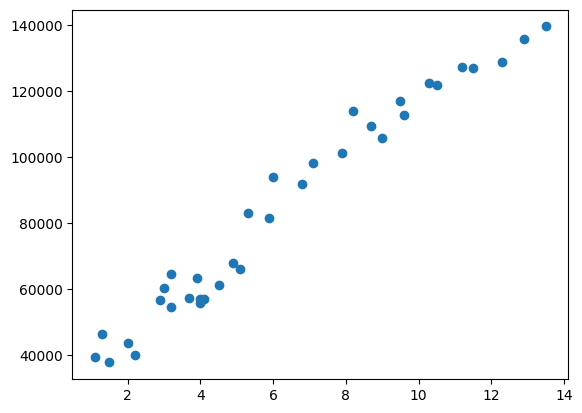

In [42]:
plt.scatter(df["YearsExperience"], df["Salary"])
plt.title("")

---
# ML Model Traning and Prediction

#### Model Creation

In [43]:
# Creating Object with class 
model = LinearRegression()

#### Train Test Spliting Data

In [44]:
#                                               2D- because one or more columns
xTrain, xTest, yTrain, Ytest = train_test_split(df[["YearsExperience"]], df["Salary"], test_size=0.2, random_state=42)

#### Training Model

In [45]:
model.fit(xTrain, yTrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Testing Model

In [46]:
#                       x ===> must be 2d array
yPrec = model.predict(xTest) # we use this for 2 senarious -- 1. Model Evaluation --2. Future Prediciton

In [47]:
(yTrain - model.predict(xTrain)).mean()

np.float64(-6.2365350978715076e-12)

#### Ploting Test Phase

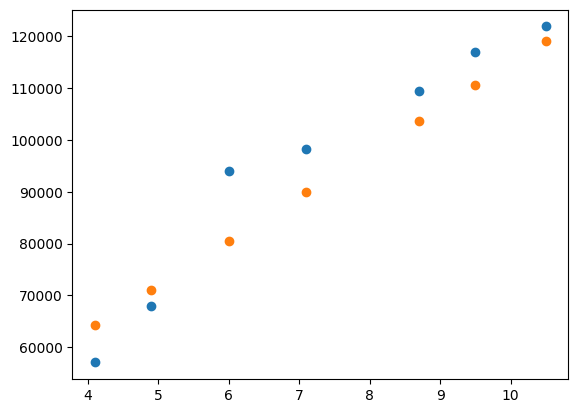

In [48]:
plt.scatter(xTest, Ytest)
plt.scatter(xTest, yPrec)

#### Model Accuracy is 0.8914234140042779

In [49]:
r2_score(Ytest, yPrec)

0.8914234140042779

In [50]:
mean_squared_error(Ytest, yPrec)

55761791.306260146

In [51]:
mean_absolute_error(Ytest, yPrec)

6692.364094497284

In [52]:
# Slope       Intercept
model.coef_, model.intercept_ # We can use only after model training

(array([8578.76747669]), np.float64(29078.626034406887))

# **Conclustion**

## Rate of change of Salary is: 8578.76747669

## Intercept(Initially) is: 29078.626034406887